# Practice 1

In [ ]:
import pandas as pd

In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/'
+ 'teaching/data-science/datasets/salaries.csv')

In [ ]:
df.head(3)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750


In [ ]:
# Qual é o salário médio dos professores em diferentes disciplinas?
    # "por disciplina" -> groupby

df.groupby('discipline')['salary'].mean()

,salary
discipline,
A,108548.430939
B,118028.694444


In [ ]:
# Qual é o salário médio e o número de professores do sexo masculino,
# da disciplina B, e que concluíram o doutorado nos últimos 5 anos?

# primeiro vamos criar uma máscara
mask = (df['sex'] == 'Male') & (df['discipline'] == 'B') & (df['yrs.since.phd'] < 5)
mask

,0
0,False
1,False
2,True
3,False
4,False
...,...
392,False
393,False
394,False
395,False


In [ ]:
# vamos aplicar essa máscara
# e pedir duas as estatísticas ao mesmo tempo (média e contagem)
df[mask]['salary'].agg(['mean', 'count']).round(2)

,salary
mean,85600.12
count,24.00


In [ ]:
# Qual é o salário médio de professores com menos de 5 anos de experiência?
# E como ele se compara ao salário daqueles com mais de 40 anos de experiência?

mask5 = df['yrs.service'] < 5
mask40 = df['yrs.service'] > 40

print(f' 5- anos: R$ {df[mask5]['salary'].mean():9.2f}')
print(f'40+ anos: R$ {df[mask40]['salary'].mean():9.2f}')

 5- anos: R$  86460.28
40+ anos: R$ 119007.14


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='salary', ylabel='Count'>

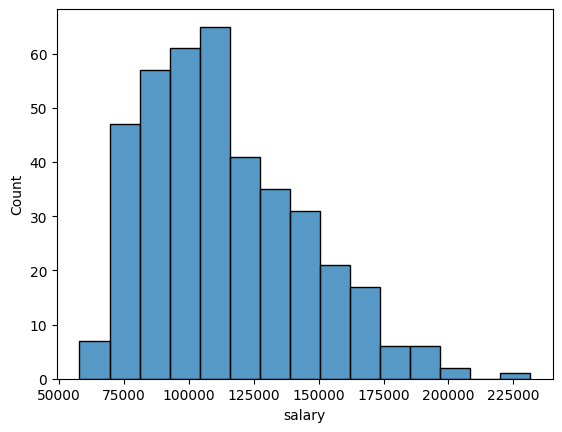

In [ ]:
sns.histplot(df['salary'])

<Axes: xlabel='salary', ylabel='Count'>

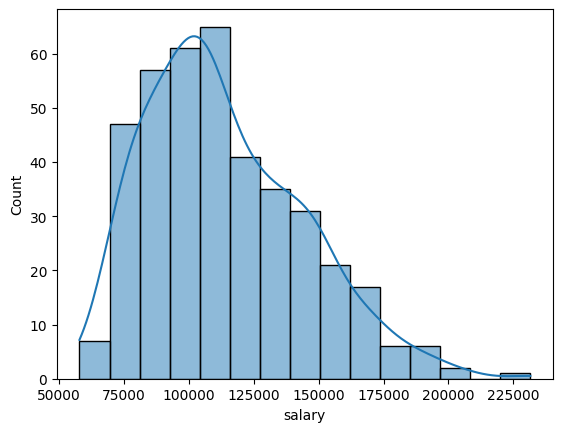

In [ ]:
sns.histplot(df['salary'], kde=True)

# KDE significa Kernel Density Estimate
# (em português, Estimativa de Densidade por Kernel).

# É uma técnica usada para estimar a distribuição de
# probabilidade contínua dos dados. Em gráficos,
# ela aparece como uma curva suave que representa a densidade dos valores.

<Axes: xlabel='salary', ylabel='Count'>

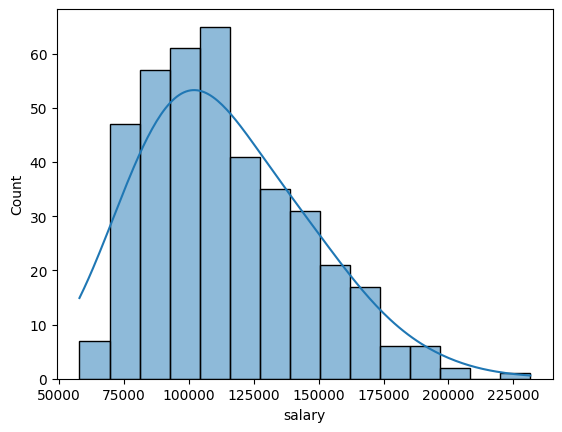

In [ ]:
# Podemos ajustar a suavização da curva
sns.histplot(df['salary'], kde=True,
             kde_kws={'bw_adjust': 2})

In [ ]:
df.head(3)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750


<Axes: xlabel='yrs.since.phd', ylabel='Count'>

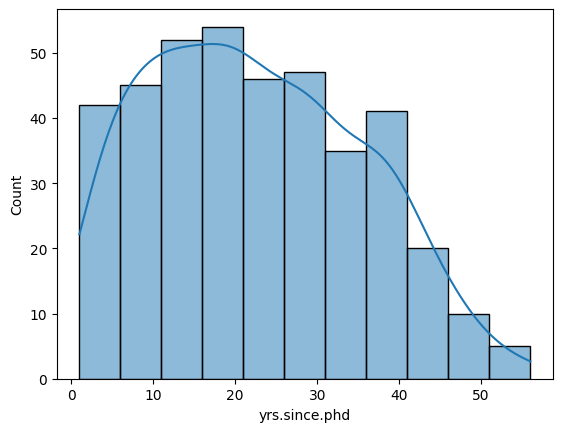

In [ ]:
# outra variável
sns.histplot(df['yrs.since.phd'], kde=True)

In [ ]:
df.head(2)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200


In [ ]:
# como quantificar assimetria ou curtose?

df.skew() # erro! (variáveis não numéricas)

TypeError: could not convert string to float: 'Prof'

In [ ]:
df['salary'].skew()

# > 1 = assimetria positiva

np.float64(0.71456845319916)

In [ ]:
df['yrs.since.phd'].skew()

# 0.30 -> assimetria positiva, mas não tanto quanto o salário

np.float64(0.3008795513246012)

In [ ]:
# Calcular a curtose e assimetria
# para todas as colunas numéricas no DataFrame
df.select_dtypes(include=['number']).agg(['kurt', 'skew'])

,Unnamed: 0,yrs.since.phd,yrs.service,salary
kurt,-1.2,-0.794417,-0.311423,0.215350
skew,0.0,0.300880,0.650569,0.714568


In [ ]:
# vamos criar a mesma variável que criamos na aula passada
df['dif_doutorado_trabalho'] = df['yrs.since.phd'] - df['yrs.service']

df.select_dtypes(include=['number']).agg(['kurt', 'skew'])

# curtose:
    # números positivos (2.23) representam distribuições LEPTOCÚRTICAS,
    # ou seja, que tem picos na distribuição
    # ou seja, valores concentrados

# assimetria:
    # valor positivo (1.31) então a cauda vai estar pra qual lado?
    # direito

,Unnamed: 0,yrs.since.phd,yrs.service,salary,dif_doutorado_trabalho
kurt,-1.2,-0.794417,-0.311423,0.215350,2.232386
skew,0.0,0.300880,0.650569,0.714568,1.316717


<Axes: xlabel='dif_doutorado_trabalho', ylabel='Count'>

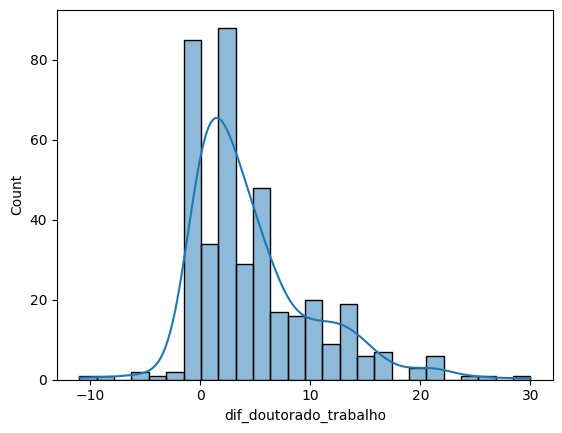

In [ ]:
# visualização
sns.histplot(df['dif_doutorado_trabalho'], kde=True)

# Tomem cuidado com a implementação!
    # Pode ser que vocês usem outra biblioteca
    # e o intervalo dos valores seja diferente.
        # Mas a ideia de curtose, assimetria, etc. é a mesma...

# Practice 2

In [ ]:
# dataset 5
df_5 = pd.read_csv('https://raysonlaroca.github.io/' +
'teaching/data-science/datasets/ans/dataset5.csv')

In [ ]:
df_5.head(3)

,x,y
0,58.213608,91.881892
1,58.196054,92.214989
2,58.718231,90.310532


In [ ]:
df_5.describe()

# x
    # mean: 54.26
    # std: 16.76

# y
    # mean: 47.83
    # std: 26.93

,x,y
count,142.000000,142.000000
mean,54.267341,47.839545
std,16.768959,26.930275
min,27.024603,14.365590
25%,41.034210,20.374135
50%,56.534732,50.110554
75%,68.711493,63.548584
max,86.435897,92.214989


<Axes: xlabel='x', ylabel='y'>

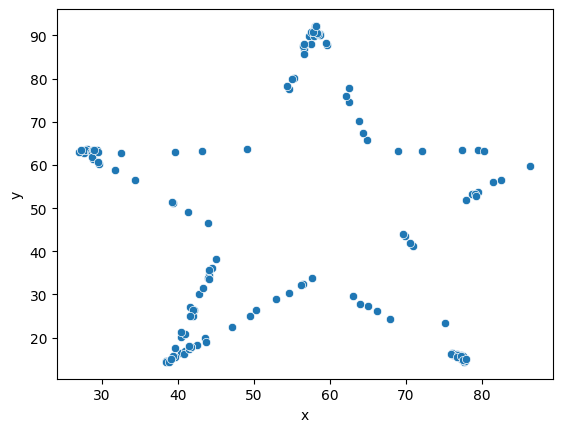

In [ ]:
sns.scatterplot(data=df_5, x='x', y='y')

In [ ]:
# agora vamos ver o dataset 0

df_0 = pd.read_csv('https://raysonlaroca.github.io/' +
'teaching/data-science/datasets/ans/dataset0.csv')

In [ ]:
df_0.head()

,x,y
0,55.3846,97.1795
1,51.5385,96.0256
2,46.1538,94.4872
3,42.8205,91.4103
4,40.7692,88.3333


In [ ]:
df_0.describe()

# x
    # mean: 54.26
    # std: 16.76

# y
    # mean: 47.83
    # std: 26.93

# obs: mesmos valores do dataset 0!

,x,y
count,142.000000,142.000000
mean,54.263273,47.832253
std,16.765142,26.935403
min,22.307700,2.948700
25%,44.102600,25.288450
50%,53.333300,46.025600
75%,64.743600,68.525675
max,98.205100,99.487200


<Axes: xlabel='x', ylabel='y'>

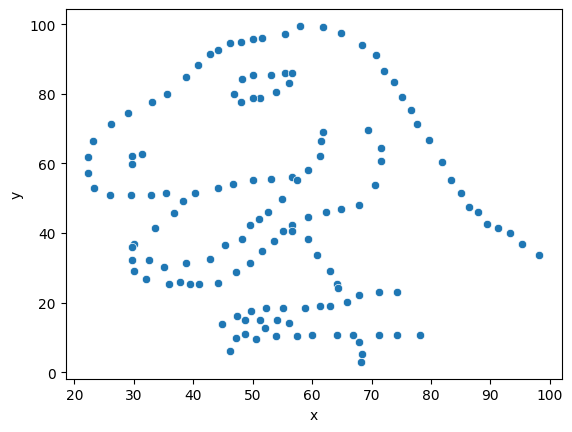

In [ ]:
sns.scatterplot(data=df_0, x='x', y='y')

In [ ]:
# insight:
# importância da visualização (tema aula que vem)
    # datasets 0 e 5 (e também os demais) têm distribuições totalmente diferentes,
    # mesmo tendo variáveis com a mesma média e desvio padrão!